In [1]:
from conv_reproj import match
from align_and_diff import a_d
from header_setup import read

from matplotlib import pyplot as plt
import numpy as np

from astropy.io import fits
from pm import pm_correct
from astropy import units as u
from astropy.wcs import WCS
import cmasher as cmr

from astropy.time import Time
from astropy.coordinates import SkyCoord
from everything import full_analysis
from radial import radial_read
from dens import density_model
from everything import plot_1d, plot_2d
import os


Match function imported.
running
Ready to go!


In [2]:
cd

/Users/iman


In [3]:
hr = 'Documents/cuny_ms/jan29_data/from_server/Betelgeuse_TE_cont_R0.image.image.tt0.fits'
lr = 'Documents/cuny_ms/jan29_data/from_server/Betelgeuse_all_cont_1-1.image.image.tt0.fits'


data3, data_1d3, radius3, data_dens_1d3, data_dens_2d3, data_plot3, info3 = full_analysis(hr,lr)
# this should be lr
info3['lr']['kspatres']
# this should be hr

False
First epoch shifted to second.
Header information imported.
Header information imported.


indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in param

Alignment and subtraction complete. Info dictionaries imported.


/Users/iman/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/iman/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:226: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/Users/iman/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:261: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/iman/anaconda3/lib/python3.11/site-packages/astropy/units/quantity.py:666: RuntimeWarning: divide by zero encountered in power
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/iman/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/iman/anaconda3/lib/python3.11/site-packages/numpy

0.040566339161841755

In [4]:
from everything import plot_1d, plot_1d_err,plot_1d_skip

Let's just do four

In [5]:
def increment(psi):
    '''
    find increment of x and y based on psi
    only input multiples of np.pi/4
    '''
    if psi == 0:
        a = 1 #coefficient of x increment
        b = 0 # coefficient of y increment
    if psi == np.pi/4:
        a = 1
        b = 1
    if psi == np.pi/2:
        a = 0
        b = 1
    if psi == 3*np.pi/4:
        a = -1
        b = 1
    if psi == np.pi:
        a = -1
        b = 0
    if psi == 5*np.pi/4:
        a = -1
        b = -1
    if psi == 3*np.pi/2:
        a = 0
        b = -1
    if psi == 7*np.pi/4:
        a = 1
        b = -1
    
    return a,b


In [6]:
n_pts = 100

In [7]:
def lines(data, cx,cy, n_pts = 100):
    '''
    psi is a multiple of pi/4
    '''
    coords = [[0]*n_pts]*8#np.zeros((8,n_pts))
    rs = [[0]*n_pts]*8#np.zeros((8,n_pts))
    line = np.zeros((8,n_pts))
    psis = np.arange(0,2*np.pi, np.pi/4)
    psi_num = 0 # index of psi we're on as we fill each ray
    #print(coords)

    for psi in psis:
      a,b = increment(psi) # find increment to follow slope of psi

      ii = np.arange(0,n_pts,1)
      line[psi_num] = data[cx+a*ii,cy+b*ii]
      coords[psi_num]=(cx+a*ii,cy+b*ii)
      rs[psi_num]=(np.sqrt(((a*ii))**2 +((b*ii))**2)) #radius is wrong when one of the values is decreasing

      psi_num += 1

    return line, coords, rs


In [8]:
def plot2d_coords(data,info, suptitle,vminmax,coords,minn=-.4, dense = False):
    maxx= -minn

    figure,ax = plt.subplots(nrows = 1, ncols=1, figsize = (5,4))#, subplot_kw={'projection': wcs})
    figure.suptitle(suptitle, fontsize = 18, y=1.01)

    xaxis = range(data.shape[0])*info['pix_size_arcsec']-((info['position'][0])*info['pix_size_arcsec'])
    yaxis = range(data.shape[1])*info['pix_size_arcsec']-((info['position'][1])*info['pix_size_arcsec'])

    im = ax.pcolormesh(yaxis,xaxis,data, cmap='gist_heat',shading="gouraud", vmin = vminmax[0], vmax = vminmax[1])

    ax.set_xlim(minn, maxx)
    ax.set_ylim(minn, maxx)
    c = ['indigo','darkorchid', 'dodgerblue', 'skyblue', 'seagreen', 'orangered','darkgoldenrod', 'darkred']
    for i in range(8):
        ax.plot(coords[i][0]*info['pix_size_arcsec']-((info['position'][0])*info['pix_size_arcsec']), 
                coords[i][1]*info['pix_size_arcsec']-((info['position'][1])*info['pix_size_arcsec']), color = c[i])


    if(dense==False):
        figure.colorbar(im,ax=ax, label=r'Jy arc$^{-2}$')
    elif (dense == True):
        figure.colorbar(im,ax=ax, label=r'g cm$^{-2}$')

    ax.set_xlabel(r'$\Delta$ RA (arc)' , size = 10)
    ax.set_ylabel(r'$\Delta$ Dec (arc)' , size = 10)



In [9]:
line_csm, coords_csm, rs_csm =  lines(data_dens_2d3['csm'].value, info3['csm']['position'][0], info3['csm']['position'][1], n_pts=n_pts)

In [10]:
data_dens_2d3['hr']

<Quantity [[ 2.95271058e-06,  2.41051457e-06,  2.97832581e-06, ...,
             8.19164363e-06,  6.11264543e-06,  4.33421964e-06],
           [-3.75085452e-06, -4.77525407e-06, -4.03638006e-06, ...,
             5.24480991e-06,  1.74335341e-06, -1.43042365e-06],
           [-8.90940039e-06, -1.01839322e-05, -9.08211719e-06, ...,
             3.52640169e-06, -1.37789193e-06, -5.82840476e-06],
           ...,
           [ 2.29486476e-05,  2.41053466e-05,  2.54650310e-05, ...,
             2.19620131e-05,  2.19532981e-05,  2.24722256e-05],
           [ 1.68521736e-05,  1.76363030e-05,  1.86901484e-05, ...,
             1.66387196e-05,  1.63701929e-05,  1.66076687e-05],
           [ 1.00778123e-05,  1.02125683e-05,  1.09192791e-05, ...,
             1.19996217e-05,  1.10614783e-05,  1.05118421e-05]] g / cm2>

In [11]:
line_hr, coords_hr, rs_hr =  lines(data_dens_2d3['hr'].value, info3['hr']['position'][0], info3['hr']['position'][1], n_pts=n_pts)

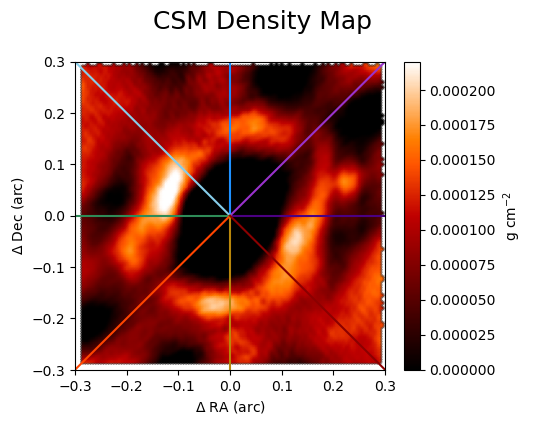

In [12]:
plot2d_coords(data_dens_2d3['csm'].value,info3['csm'],suptitle='CSM Density Map', vminmax = [0,.00022],coords = coords_csm,minn=-.3, dense =True)

In [13]:
info3['hr']['position'][0]*info3['hr']['pix_size_arcsec'],info3['hr']['position'][1]*info3['hr']['pix_size_arcsec']

(<Quantity 0.3 arcsec>, <Quantity 0.288 arcsec>)

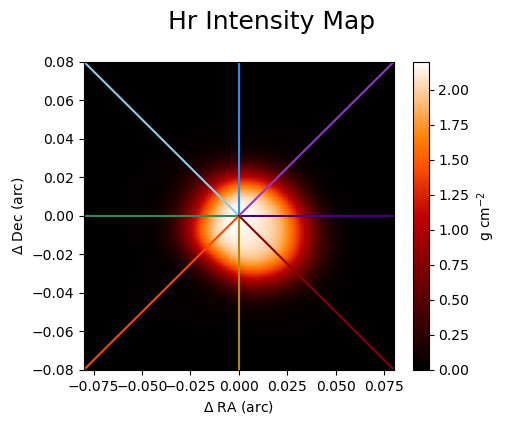

In [14]:
plot2d_coords(data3['hr']['jy_arc2'][0,0,...].value,info3['hr'],suptitle='Hr Intensity Map',coords = coords_hr, vminmax = [0,2.2],minn=-.08, dense =True)


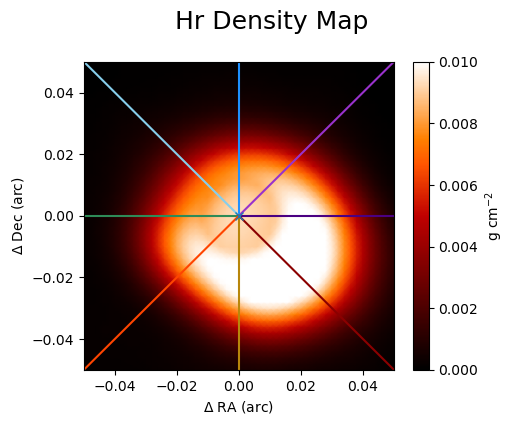

In [15]:
plot2d_coords(data_dens_2d3['hr'].value,info3['hr'],suptitle='Hr Density Map', vminmax = [0,.01],coords = coords_hr,minn=-.05, dense =True)
plt.plot(0,0, 'x')

Note: Peak lowered because of temperature cap

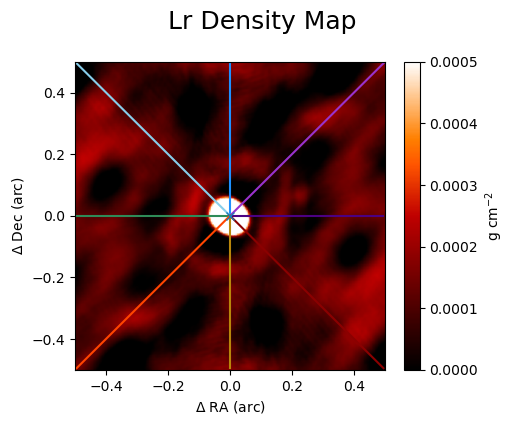

In [16]:
plot2d_coords(data_dens_2d3['lr'].value,info3['lr'],suptitle='Lr Density Map', coords = coords_csm,vminmax = [0,.0005],minn=-.5, dense =True)
plt.plot(0,0, 'x')

# abel

In [17]:
from abel import all_abel, do_abel, plot_1d_abel

In [18]:
from radial import sm

In [19]:
rs_csm

[array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
        13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25.,
        26., 27., 28., 29., 30., 31., 32., 33., 34., 35., 36., 37., 38.,
        39., 40., 41., 42., 43., 44., 45., 46., 47., 48., 49., 50., 51.,
        52., 53., 54., 55., 56., 57., 58., 59., 60., 61., 62., 63., 64.,
        65., 66., 67., 68., 69., 70., 71., 72., 73., 74., 75., 76., 77.,
        78., 79., 80., 81., 82., 83., 84., 85., 86., 87., 88., 89., 90.,
        91., 92., 93., 94., 95., 96., 97., 98., 99.]),
 array([  0.        ,   1.41421356,   2.82842712,   4.24264069,
          5.65685425,   7.07106781,   8.48528137,   9.89949494,
         11.3137085 ,  12.72792206,  14.14213562,  15.55634919,
         16.97056275,  18.38477631,  19.79898987,  21.21320344,
         22.627417  ,  24.04163056,  25.45584412,  26.87005769,
         28.28427125,  29.69848481,  31.11269837,  32.52691193,
         33.9411255 ,  35.35533906,  36.76955262, 

In [20]:
r_arc_csm = rs_csm*info3['csm']['pix_size_arcsec']
r_pc_csm = sm(168,r_arc_csm).value*u.pc

In [21]:
abels_csm = [[0]*n_pts]*8
for i in range(8):
    abels_csm[i] = do_abel(line_csm[i,:],r_pc_csm[0].to(u.cm).value,info3['csm']['median_dens'])

In [22]:
def plot_1d_abel(data_abel_1d,radius,ax_ymin=1e-2, ax_ymax=1e4,xmin=0,xmax=0.45, suptitle = "1D Abel Transformation (g/cm3)", dent=False):
    '''
    plot 1d density and intensity functions.
    can select plot x and y limits. default values inputted otherwise
    '''


    plt.rcParams["font.family"] = "times"
    fig, axes = plt.subplots(8, 1, figsize = [7,13])
    fig.suptitle(suptitle,y=.9)

    labels = [r'$\Psi$ = 0',r'$\Psi$ = $\pi$/4',r'$\Psi$ = $\pi$/2',r'$\Psi$ = $3\pi$/4',r'$\Psi$ = $\pi$',
             r'$\Psi$ = $5\pi$/4',r'$\Psi$ = $3\pi$/2',r'$\Psi$ = $7\pi$/4']
    c = ['indigo','darkorchid', 'dodgerblue', 'skyblue', 'seagreen', 'orangered','darkgoldenrod', 'darkred']
    axes[0].set_ylabel(r'Density (g cm$^{-3}$)')
    
    for i in range(8):
            ax = axes[i]
            ax.plot(radius[i][:len(data_abel_1d[i])],data_abel_1d[i],'o-',alpha=0.4, label = labels[i],color=c[i])
            ax.set_xlim(xmin,xmax)
            ax.set_ylim(ax_ymin, ax_ymax)
            ax.semilogy()
            ax.legend(loc = 'right')#bbox_to_anchor=(0.5, 0.5, 0.5, 0.5))
            
            #ax.errorbar(radius[title[c]]['arc_1d'],data_1d[title[c]].value,yerr=info[title[c]]['error'].value, c = color[c])

    

    if(dent == True):
         m_e = 9.109e-28 # electron mass in g
         m_p = 1.6726e-24
         plt.axhline(y=(m_e+m_p)*3e8/(0.7), label = "Dent 2025",color = 'black', ls = ':')
         plt.axhline(y=(m_e+m_p)*2e8/(0.7), label = "Judge 1998", color = 'red', ls = '--')
         plt.axhline(y=(m_e+m_p)*1e9/(0.7), label = "Harper 2006", color = 'orange',ls = '-.')
         
#     ax.set_title("1-D Density (g/cm3)")
    ax.set_xlabel('Radius (arc)')

    ax.semilogy()
    ax.semilogx()



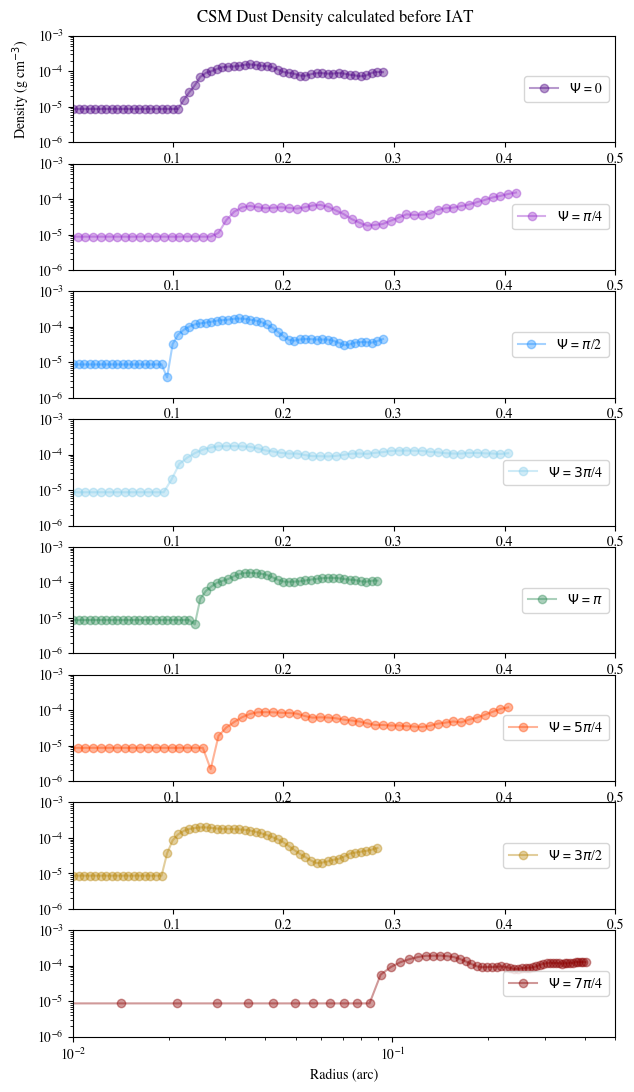

In [23]:
plot_1d_abel(line_csm,r_arc_csm,ax_ymin=1e-6,ax_ymax=1e-3,xmin = 0.01,xmax = .5, suptitle = "CSM Dust Density calculated before IAT")

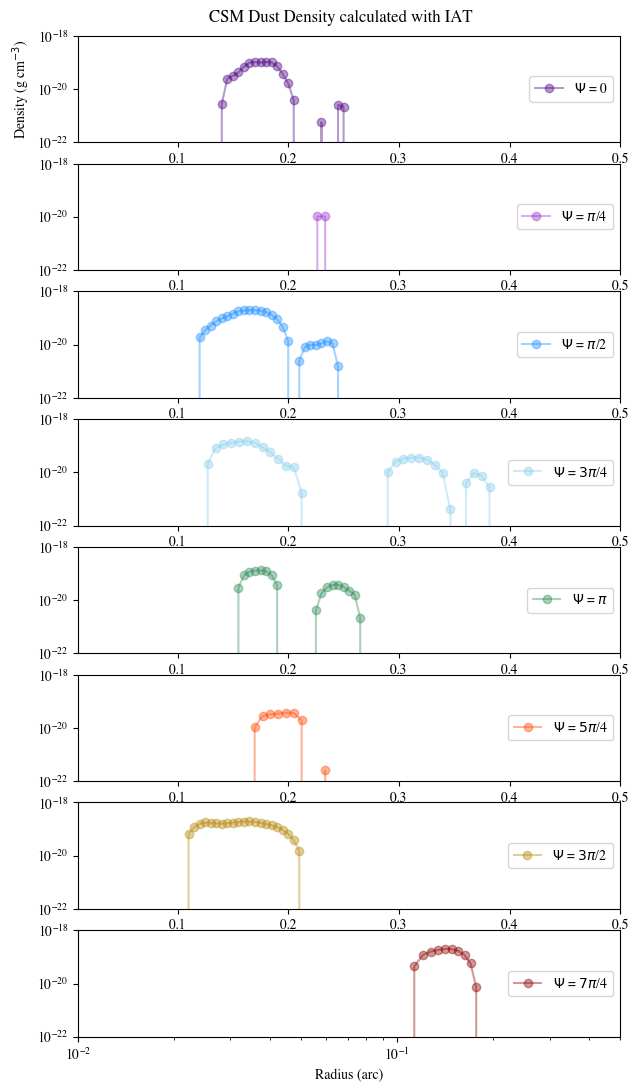

In [24]:
plot_1d_abel(abels_csm,r_arc_csm,ax_ymin=1e-22,ax_ymax=1e-18,xmin=0.01,xmax=0.5,suptitle = "CSM Dust Density calculated with IAT")


In [25]:
m_e = 9.109e-28 # electron mass in g
m_p = 1.6726e-24

harper_nh_1_33_rstar = (m_e+m_p)*1e11/(0.7) #1.33 rstar, nh ~ 10^11

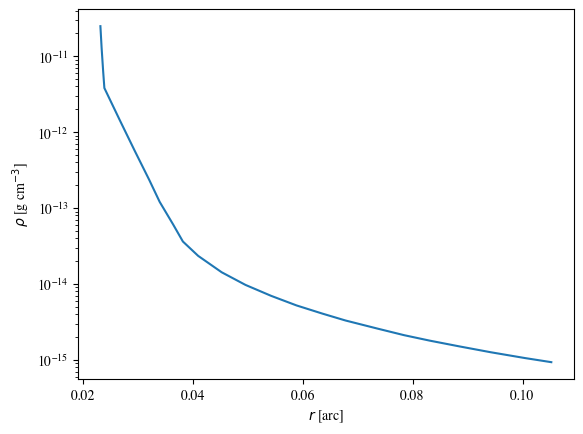

In [26]:
# H density from Dent et al via webplotdigitizer
data_dent = np.asarray([[1.0801033591731268, 13.018018018018019],
[1.0904392764857884, 12.729729729729732],
[1.103359173126615, 12.423423423423424],
[1.1136950904392768, 12.202702702702704],
[1.245478036175711, 11.774774774774775],
[1.3695090439276487, 11.378378378378379],
[1.4935400516795867, 10.99099099099099],
[1.5813953488372094, 10.702702702702704],
[1.6950904392764858, 10.405405405405405],
[1.7777777777777781, 10.18018018018018],
[1.9069767441860466, 9.99099099099099],
[2.1059431524547803, 9.774774774774775],
[2.30749354005168, 9.608108108108109],
[2.524547803617571, 9.463963963963964],
[2.739018087855297, 9.337837837837839],
[2.9586563307493536, 9.22972972972973],
[3.152454780361757, 9.13963963963964],
[3.4263565891472867, 9.031531531531531],
[3.648578811369509, 8.945945945945946],
[3.8656330749354, 8.873873873873872],
[4.118863049095607, 8.797297297297298],
[4.3824289405684755, 8.72072072072072],
[4.671834625322997, 8.644144144144143],
[4.89405684754522, 8.59009009009009],]).T

# pN = mr.MesaData()

fig, ax = plt.subplots()
xaxis_dent = data_dent[0]*21.5/1000
yaxis_dent = 10**data_dent[1] * 1.6735575e-24 * (1/0.7)
# ax.plot([2*scale,4*scale], [1e-13, 1e-13/4], linestyle='dashed', color='k')
# ax.plot([2*scale,4*scale], [1e-13, 1e-13/8], linestyle='dashed', color='k')
ax.plot(xaxis_dent, yaxis_dent)
# ax.set_xscale('log')
ax.set_yscale('log')
#ax.set_xscale('log')
ax.set_xlabel(r'$r$ [arc]')
ax.set_ylabel(r'$\rho$ [g cm$^{-3}$]')
plt.show()

In [27]:
def plot_1d_abel_distribution_rstar(data_abel_1d,radius,ax_ymin=1e-2, ax_ymax=1e4,xmin=0,xmax=10, suptitle = "1D Abel Transformation (g/cm3)", dent=False):
    '''
    plot 1d density and intensity functions.
    can select plot x and y limits. default values inputted otherwise
    '''

    fig, axes = plt.subplots(8,1,figsize = [7,16])
    fig.suptitle(suptitle, y=.9)

    labels = [r'$\Psi$ = 0',r'$\Psi$ = $\pi$/4',r'$\Psi$ = $\pi$/2',r'$\Psi$ = $3\pi$/4',r'$\Psi$ = $\pi$',
             r'$\Psi$ = $5\pi$/4',r'$\Psi$ = $3\pi$/2',r'$\Psi$ = $7\pi$/4']
    c = ['indigo','darkorchid', 'dodgerblue', 'skyblue', 'seagreen', 'orangered','darkgoldenrod', 'darkred']


    for i in range(8):
        ax = axes[i]
        ax.fill_between((radius[i][:len(data_abel_1d[i])]/0.0295).value,data_abel_1d[i]+data_abel_1d[i]*430,data_abel_1d[i]+data_abel_1d[i]*1000,
                        alpha=0.6, label = labels[i], color = c[i])
        ax.legend(loc = 'best', bbox_to_anchor=(0.5, 0.5, 0.5, 0.5))

        ax.semilogy()
        ax.set_xlim(xmin,xmax)
        ax.set_ylim(ax_ymin, ax_ymax)
 
    

    # if(dent == True):
    #      #plt.plot(xaxis/0.0215,yaxis, label = ("Dent et al 2025"),color = 'black')
    #     xaxis_dent = data_dent[0]*21.5/1000
    #     yaxis_dent = 10**data_dent[1] * 1.6735575e-24 * (1/0.7)
    #     plt.plot(xaxis_dent/0.0295,yaxis_dent, label = ("Dent et al 2025"),color = 'black')
    #     plt.plot(1.33, harper_nh_1_33_rstar, 'x', label = r'Harper 2006, $n_h, 1.33$R_*$')



    # ax.axvline(x=1, c = 'red', label = 'R_star = 1', ls = 'dashed')

    # ax.legend(loc = 'best', bbox_to_anchor=(0.5, 0.5, 0.5, 0.5))
    # ax.set_xlim(xmin,xmax)
    # #ax.set_xlim(0,0.45)
    # ax.set_ylim(ax_ymin, ax_ymax)
    # ax.set_ylim(ax_ymin, ax_ymax)

    
#     ax.set_title("1-D Density (g/cm3)")
    ax.set_xlabel(r'Radius [$R_{*}$]')
    axes[0].set_ylabel(r'Density [g cm$^{-3}$]')


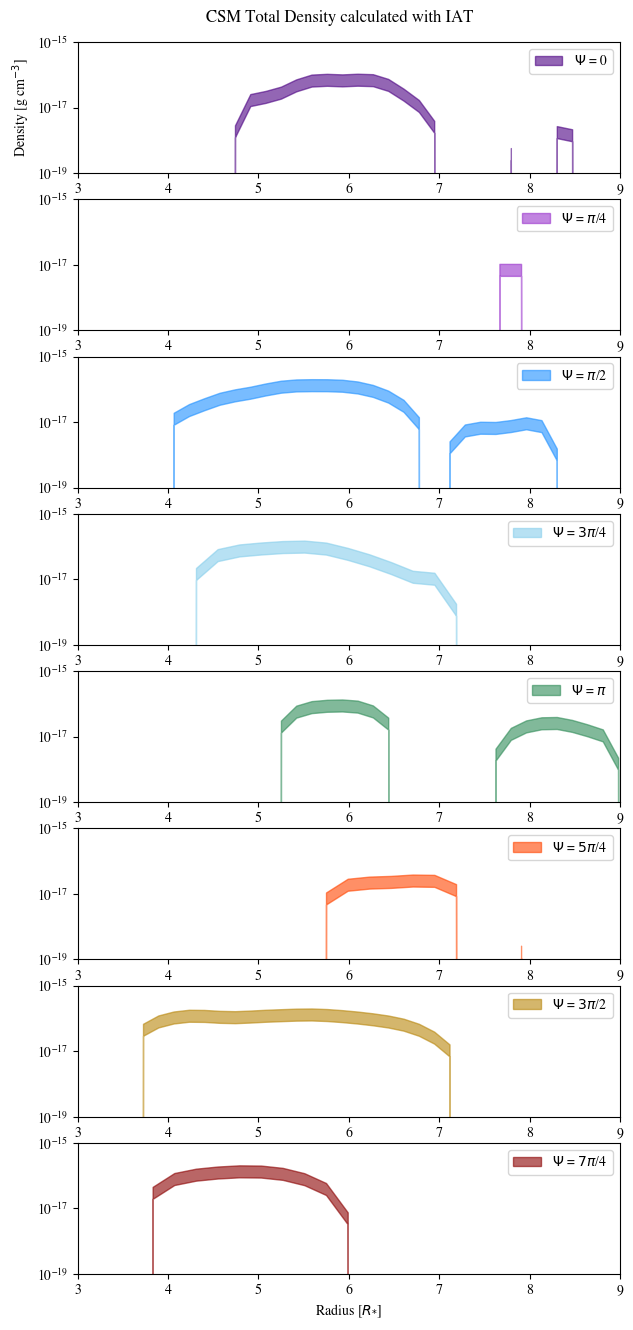

In [28]:
plot_1d_abel_distribution_rstar(abels_csm,r_arc_csm,ax_ymin=1e-19,ax_ymax=1e-15,xmin=3,xmax=9,suptitle = "CSM Total Density calculated with IAT")


In [49]:
def plot_1d_abel_distribution_rarc(data_abel_1d,radius,ax_ymin=1e-2, ax_ymax=1e4,xmin=0,xmax=10, suptitle = "1D Abel Transformation (g/cm3)", dent=False):
    '''
    plot 1d density and intensity functions.
    can select plot x and y limits. default values inputted otherwise
    '''

    fig, axes = plt.subplots(8,1,figsize = [7,16])
    fig.suptitle(suptitle, y=.9)

    labels = [r'$\Psi$ = 0',r'$\Psi$ = $\pi$/4',r'$\Psi$ = $\pi$/2',r'$\Psi$ = $3\pi$/4',r'$\Psi$ = $\pi$',
             r'$\Psi$ = $5\pi$/4',r'$\Psi$ = $3\pi$/2',r'$\Psi$ = $7\pi$/4']
    c = ['indigo','darkorchid', 'dodgerblue', 'skyblue', 'seagreen', 'orangered','darkgoldenrod', 'darkred']


    for i in range(8):
        ax = axes[i]
        ax.fill_between((radius[i][:len(data_abel_1d[i])]).value,data_abel_1d[i]+data_abel_1d[i]*430,data_abel_1d[i]+data_abel_1d[i]*1000,
                        alpha=0.6, label = labels[i], color = c[i])
        ax.legend(loc = 'best', bbox_to_anchor=(0.5, 0.5, 0.5, 0.5))

        ax.semilogy()
        ax.set_xlim(xmin,xmax)
        ax.set_ylim(ax_ymin, ax_ymax)
 
    

    # if(dent == True):
    #      #plt.plot(xaxis/0.0215,yaxis, label = ("Dent et al 2025"),color = 'black')
    #     xaxis_dent = data_dent[0]*21.5/1000
    #     yaxis_dent = 10**data_dent[1] * 1.6735575e-24 * (1/0.7)
    #     plt.plot(xaxis_dent/0.0295,yaxis_dent, label = ("Dent et al 2025"),color = 'black')
    #     plt.plot(1.33, harper_nh_1_33_rstar, 'x', label = r'Harper 2006, $n_h, 1.33$R_*$')



    # ax.axvline(x=1, c = 'red', label = 'R_star = 1', ls = 'dashed')

    # ax.legend(loc = 'best', bbox_to_anchor=(0.5, 0.5, 0.5, 0.5))
    # ax.set_xlim(xmin,xmax)
    # #ax.set_xlim(0,0.45)
    # ax.set_ylim(ax_ymin, ax_ymax)
    # ax.set_ylim(ax_ymin, ax_ymax)

    
#     ax.set_title("1-D Density (g/cm3)")
    ax.set_xlabel(r'Radius (arc)')
    axes[0].set_ylabel(r'Density [g cm$^{-3}$]')


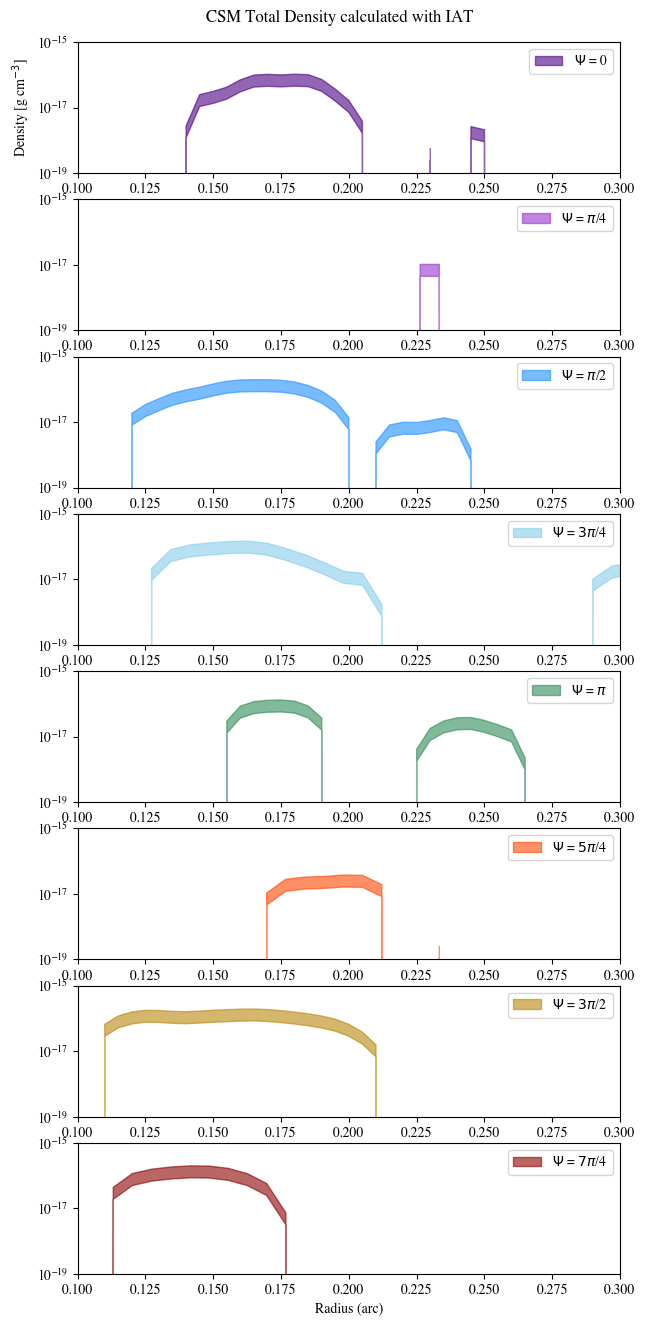

In [50]:
plot_1d_abel_distribution_rarc(abels_csm,r_arc_csm,ax_ymin=1e-19,ax_ymax=1e-15,xmin=0.1,xmax=.3,suptitle = "CSM Total Density calculated with IAT")


In [46]:
def plot_1d_distribution_rstar(data_abel_1d,radius,ax_ymin=1e-2, ax_ymax=1e4,xmin=0,xmax=10, suptitle = "1D Abel Transformation (g/cm3)", dent=False):
    '''
    plot 1d density and intensity functions.
    can select plot x and y limits. default values inputted otherwise
    '''

    fig, axes = plt.subplots(8,1,figsize = [7,13])
    fig.suptitle(suptitle, y=.9)

    labels = [r'$\Psi$ = 0',r'$\Psi$ = $\pi$/4',r'$\Psi$ = $\pi$/2',r'$\Psi$ = $3\pi$/4',r'$\Psi$ = $\pi$',
             r'$\Psi$ = $5\pi$/4',r'$\Psi$ = $3\pi$/2',r'$\Psi$ = $7\pi$/4']
    c = ['indigo','darkorchid', 'dodgerblue', 'skyblue', 'seagreen', 'orangered','darkgoldenrod', 'darkred']

    axes[0].set_ylabel(r'Density [g cm$^{-3}$]')
    for i in range(8):
        ax = axes[i]
        ax.plot(radius[i][:len(data_abel_1d[i])]/0.0295,data_abel_1d[i],'o-',alpha=0.4, label = labels[i],color=c[i])
        # ax.plot(radius[i]/0.0295.value,data_abel_1d[i],
        #                 alpha=0.6, label = labels[i], color = c[i])
        ax.legend(loc = 'best', bbox_to_anchor=(0.5, 0.5, 0.5, 0.5))

        ax.semilogy()
        ax.set_xlim(xmin,xmax)
        ax.set_ylim(ax_ymin, ax_ymax)
 
    

    # if(dent == True):
    #      #plt.plot(xaxis/0.0215,yaxis, label = ("Dent et al 2025"),color = 'black')
    #     xaxis_dent = data_dent[0]*21.5/1000
    #     yaxis_dent = 10**data_dent[1] * 1.6735575e-24 * (1/0.7)
    #     plt.plot(xaxis_dent/0.0295,yaxis_dent, label = ("Dent et al 2025"),color = 'black')
    #     plt.plot(1.33, harper_nh_1_33_rstar, 'x', label = r'Harper 2006, $n_h, 1.33$R_*$')



    # ax.axvline(x=1, c = 'red', label = 'R_star = 1', ls = 'dashed')

    # ax.legend(loc = 'best', bbox_to_anchor=(0.5, 0.5, 0.5, 0.5))
    # ax.set_xlim(xmin,xmax)
    # #ax.set_xlim(0,0.45)
    # ax.set_ylim(ax_ymin, ax_ymax)
    # ax.set_ylim(ax_ymin, ax_ymax)

    
#     ax.set_title("1-D Density (g/cm3)")
    ax.set_xlabel(r'Radius [$R_{*}$]')



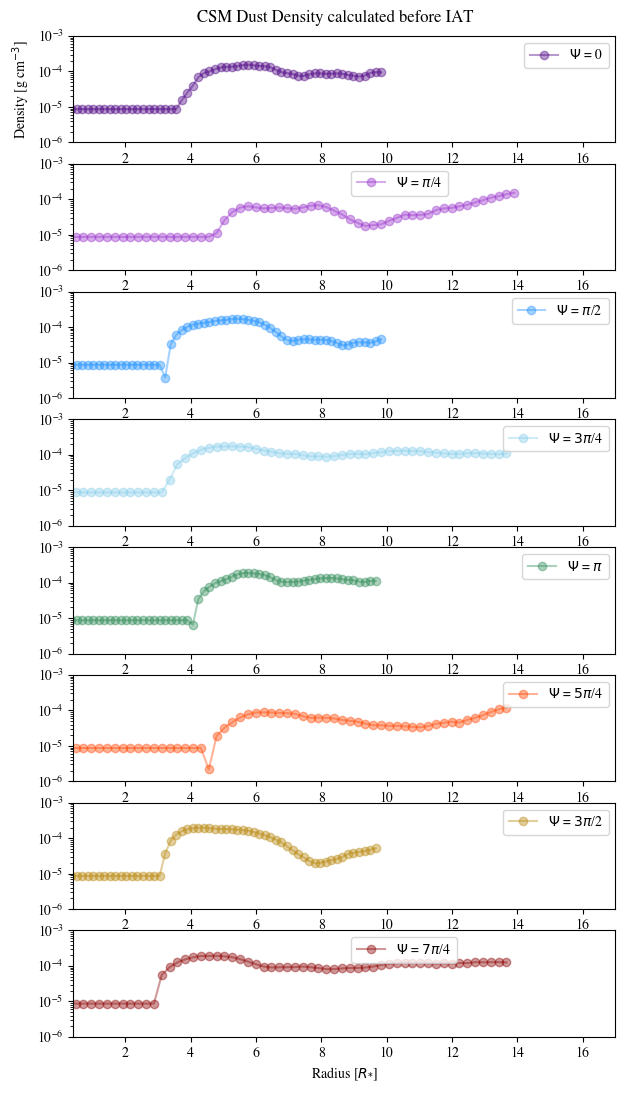

In [32]:
plot_1d_distribution_rstar(line_csm,r_arc_csm,ax_ymin=1e-6,ax_ymax=1e-3,xmin=0.4,xmax=17,suptitle = "CSM Dust Density calculated before IAT")

In [33]:
npts = 100

In [34]:
line_hr, coords_hr, rs_hr =  lines(data_dens_2d3['hr'].value, info3['hr']['position'][0], info3['hr']['position'][1], n_pts=n_pts)

In [35]:

r_arc_hr = rs_hr*info3['hr']['pix_size_arcsec']
r_pc_hr = sm(168,r_arc_hr).value*u.pc

abels_hr = [[0]*n_pts]*8
for i in range(8):
    abels_hr[i] = do_abel(line_hr[i,:],r_pc_hr[0].to(u.cm).value,info3['hr']['median_dens'])

In [36]:
r_arc_hr

<Quantity [[0.        , 0.002     , 0.004     , 0.006     , 0.008     ,
            0.01      , 0.012     , 0.014     , 0.016     , 0.018     ,
            0.02      , 0.022     , 0.024     , 0.026     , 0.028     ,
            0.03      , 0.032     , 0.034     , 0.036     , 0.038     ,
            0.04      , 0.042     , 0.044     , 0.046     , 0.048     ,
            0.05      , 0.052     , 0.054     , 0.056     , 0.058     ,
            0.06      , 0.062     , 0.064     , 0.066     , 0.068     ,
            0.07      , 0.072     , 0.074     , 0.076     , 0.078     ,
            0.08      , 0.082     , 0.084     , 0.086     , 0.088     ,
            0.09      , 0.092     , 0.094     , 0.096     , 0.098     ,
            0.1       , 0.102     , 0.104     , 0.106     , 0.108     ,
            0.11      , 0.112     , 0.114     , 0.116     , 0.118     ,
            0.12      , 0.122     , 0.124     , 0.126     , 0.128     ,
            0.13      , 0.132     , 0.134     , 0.136     , 0.13

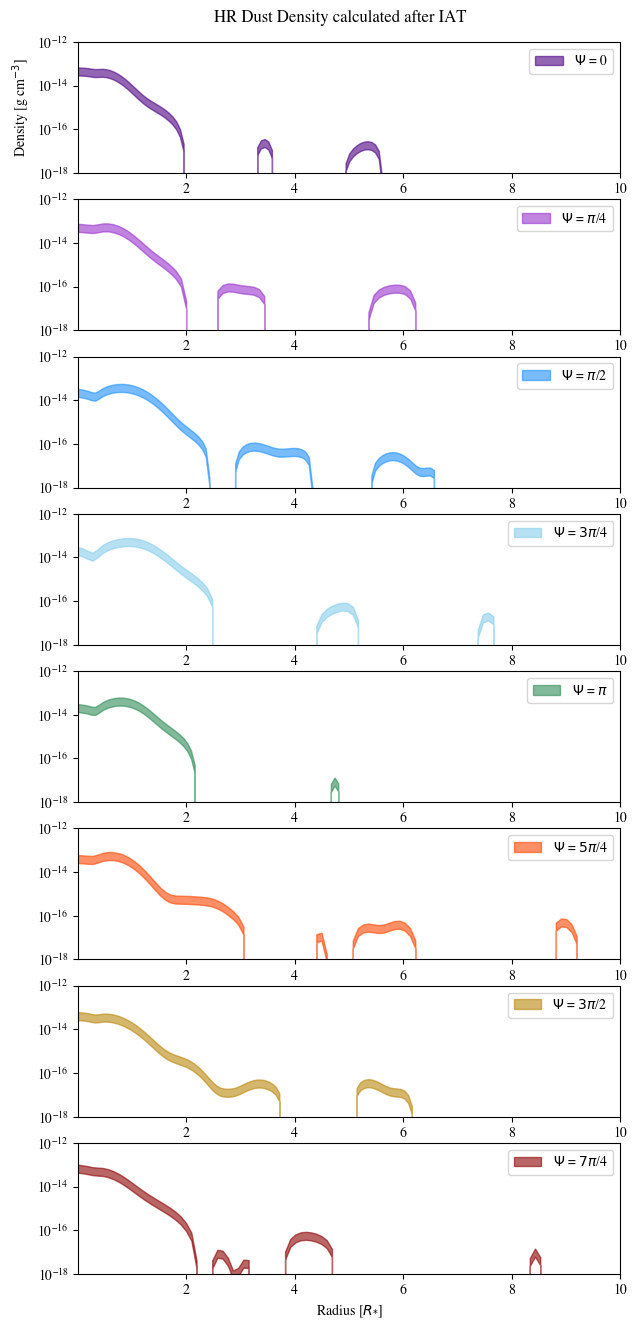

In [37]:
plot_1d_abel_distribution_rstar(abels_hr,r_arc_hr,ax_ymin=1e-18,ax_ymax=1e-12,xmin = 0.01,xmax = 10, suptitle = "HR Dust Density calculated after IAT")

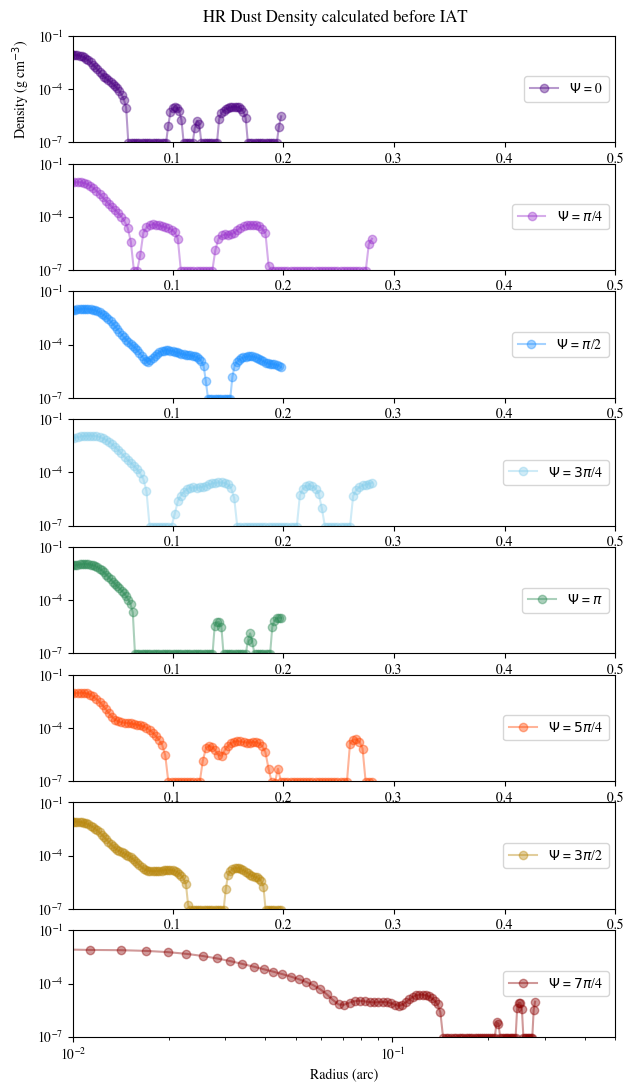

In [38]:
plot_1d_abel(line_hr,r_arc_hr,ax_ymin=1e-7,ax_ymax=1e-1,xmin = 0.01,xmax = .5, suptitle = "HR Dust Density calculated before IAT")

In [39]:
abels_hr

[array([ 6.52573948e-17,  6.39287431e-17,  6.25910600e-17,  6.03319615e-17,
         5.68127090e-17,  5.42325761e-17,  5.51298602e-17,  5.60721522e-17,
         5.36560487e-17,  4.85635393e-17,  4.16946772e-17,  3.40379730e-17,
         2.64989591e-17,  1.97584755e-17,  1.42049236e-17,  9.94718108e-18,
         6.88458716e-18,  4.79815752e-18,  3.43247687e-18,  2.55219366e-18,
         1.97112696e-18,  1.55993336e-18,  1.24021104e-18,  9.71844993e-19,
         7.38730709e-19,  5.36469105e-19,  3.63920916e-19,  2.18439625e-19,
         9.91799939e-20,  2.06876071e-20, -5.05600209e-21, -5.19829665e-21,
        -5.35811541e-21, -5.53875740e-21, -5.74443873e-21, -5.98063472e-21,
        -6.25458768e-21, -6.57608179e-21, -6.95866540e-21, -7.42165524e-21,
        -7.99358036e-21, -8.71845158e-21, -9.66804822e-21, -1.09684921e-20,
        -1.28664997e-20, -1.59383077e-20, -2.04938877e-20, -2.09387480e-20,
        -7.10205978e-21,  1.44488662e-20,  2.96902877e-20,  3.42034393e-20,
         2.6

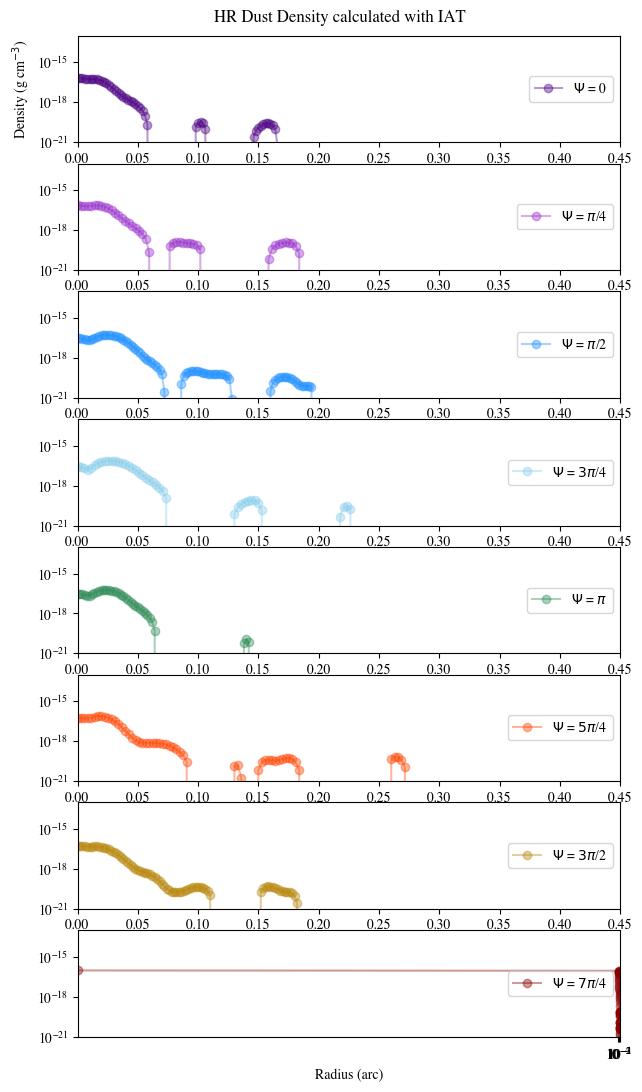

In [40]:
plot_1d_abel(abels_hr,r_arc_hr,ax_ymin=1e-21,ax_ymax=1e-13, suptitle = "HR Dust Density calculated with IAT")

In [41]:
r_arc_hr.value

array([[0.        , 0.002     , 0.004     , 0.006     , 0.008     ,
        0.01      , 0.012     , 0.014     , 0.016     , 0.018     ,
        0.02      , 0.022     , 0.024     , 0.026     , 0.028     ,
        0.03      , 0.032     , 0.034     , 0.036     , 0.038     ,
        0.04      , 0.042     , 0.044     , 0.046     , 0.048     ,
        0.05      , 0.052     , 0.054     , 0.056     , 0.058     ,
        0.06      , 0.062     , 0.064     , 0.066     , 0.068     ,
        0.07      , 0.072     , 0.074     , 0.076     , 0.078     ,
        0.08      , 0.082     , 0.084     , 0.086     , 0.088     ,
        0.09      , 0.092     , 0.094     , 0.096     , 0.098     ,
        0.1       , 0.102     , 0.104     , 0.106     , 0.108     ,
        0.11      , 0.112     , 0.114     , 0.116     , 0.118     ,
        0.12      , 0.122     , 0.124     , 0.126     , 0.128     ,
        0.13      , 0.132     , 0.134     , 0.136     , 0.138     ,
        0.14      , 0.142     , 0.144     , 0.14

In [42]:
np.set_printoptions(linewidth=np.inf)


In [43]:
from IPython.display import display, HTML
display(HTML("<style>div.jp-OutputArea-output pre {white-space: pre;}</style>"))